In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
MAX_VAL = 2**32

## Steps A and B: Generate keys and server IDs


In [2]:
keys = np.floor(np.random.rand(10_000) * MAX_VAL).astype(np.uint64)

n_servers = 100
server_ids = np.floor(np.random.rand(n_servers) * MAX_VAL).astype(np.uint64)

print(f"Generated {len(keys)} keys and {len(server_ids)} server IDs")
print(f"Key range: [{keys.min()}, {keys.max()}]")
print(f"Server ID range: [{server_ids.min()}, {server_ids.max()}]")

Generated 10000 keys and 100 server IDs
Key range: [49970, 4293754711]
Server ID range: [4050336, 4231433244]


In [9]:
def assign_keys(keys, ring_ids, *, ring_to_physical=None, n_physical=None):
    ring_ids = np.asarray(ring_ids)

    sorted_indices = np.argsort(ring_ids)
    sorted_ring = ring_ids[sorted_indices]

    if ring_to_physical is None:
        n = len(ring_ids) if n_physical is None else n_physical
        loads = np.zeros(n, dtype=np.int64)

        for key in keys:
            pos = np.searchsorted(sorted_ring, key, side='left')
            if pos == len(sorted_ring):
                pos = 0
            physical_idx = sorted_indices[pos]  # 0..len(ring_ids)-1
            loads[physical_idx] += 1

        return loads

    if n_physical is None:
        raise ValueError("n_physical must be provided when ring_to_physical is used")

    loads = np.zeros(n_physical, dtype=np.int64)

    for key in keys:
        pos = np.searchsorted(sorted_ring, key, side='left')
        if pos == len(sorted_ring):
            pos = 0
        chosen_virtual_id = sorted_ring[pos]
        physical_idx = ring_to_physical[int(chosen_virtual_id)]
        loads[physical_idx] += 1

    return loads

loads_no_virtual = assign_keys(keys, server_ids)
print(f"Total keys assigned: {loads_no_virtual.sum()}")

Total keys assigned: 10000


In [10]:
def compute_stats(loads, label):
    stats = {
        'Min': np.min(loads),
        '25th Percentile': np.percentile(loads, 25),
        'Median': np.median(loads),
        'Average': np.mean(loads),
        '75th Percentile': np.percentile(loads, 75),
        'Max': np.max(loads),
    }
    print(f"--- {label} ---")
    for k, v in stats.items():
        print(f"  {k}: {v:.2f}")
    return stats

stats_no_virtual = compute_stats(loads_no_virtual, "Without Virtual Nodes")

--- Without Virtual Nodes ---
  Min: 0.00
  25th Percentile: 24.00
  Median: 69.00
  Average: 100.00
  75th Percentile: 144.50
  Max: 454.00


## E: Create 5 virtual copies per server


In [11]:
n_virtual = 5
virtual_ring_ids = []
ring_to_physical = {}

for physical_idx, sid in enumerate(server_ids):
    for r in range(n_virtual):
        vid = (hash((int(sid), r)) % MAX_VAL)
        virtual_ring_ids.append(vid)
        ring_to_physical[vid] = physical_idx

virtual_ring_ids = np.array(virtual_ring_ids, dtype=np.uint64)

counts = np.bincount(list(ring_to_physical.values()), minlength=len(server_ids))
print(counts.min(), counts.max())

5 5


In [12]:
loads_virtual = assign_keys(keys,virtual_ring_ids,ring_to_physical=ring_to_physical,n_physical=len(server_ids))
stats_virtual = compute_stats(loads_virtual, "With Virtual Nodes (5 copies)")

--- With Virtual Nodes (5 copies) ---
  Min: 10.00
  25th Percentile: 54.75
  Median: 92.00
  Average: 100.00
  75th Percentile: 133.50
  Max: 271.00


In [15]:
import pandas as pd

comparison = pd.DataFrame({
    'Without Virtual Nodes': stats_no_virtual,
    'With Virtual Nodes (5 copies)': stats_virtual,
})
comparison['Difference'] = comparison['With Virtual Nodes (5 copies)'] - comparison['Without Virtual Nodes']
print(comparison.to_string())


                 Without Virtual Nodes  With Virtual Nodes (5 copies)  Difference
Min                                0.0                          10.00       10.00
25th Percentile                   24.0                          54.75       30.75
Median                            69.0                          92.00       23.00
Average                          100.0                         100.00        0.00
75th Percentile                  144.5                         133.50      -11.00
Max                              454.0                         271.00     -183.00


The average load remains the same in both scenarios because the total number of keys and physical servers does not change.
With virtual nodes, the minimum, median, and lower percentiles increase because each physical server is represented multiple times on the hash ring, reducing the chance that a server is assigned a very small interval.
At the same time, the maximum load decreases because large intervals on the ring are split among several virtual nodes, preventing any single server from becoming a bottleneck.
As a result, the configuration with virtual copies achieves better load balancing on average.

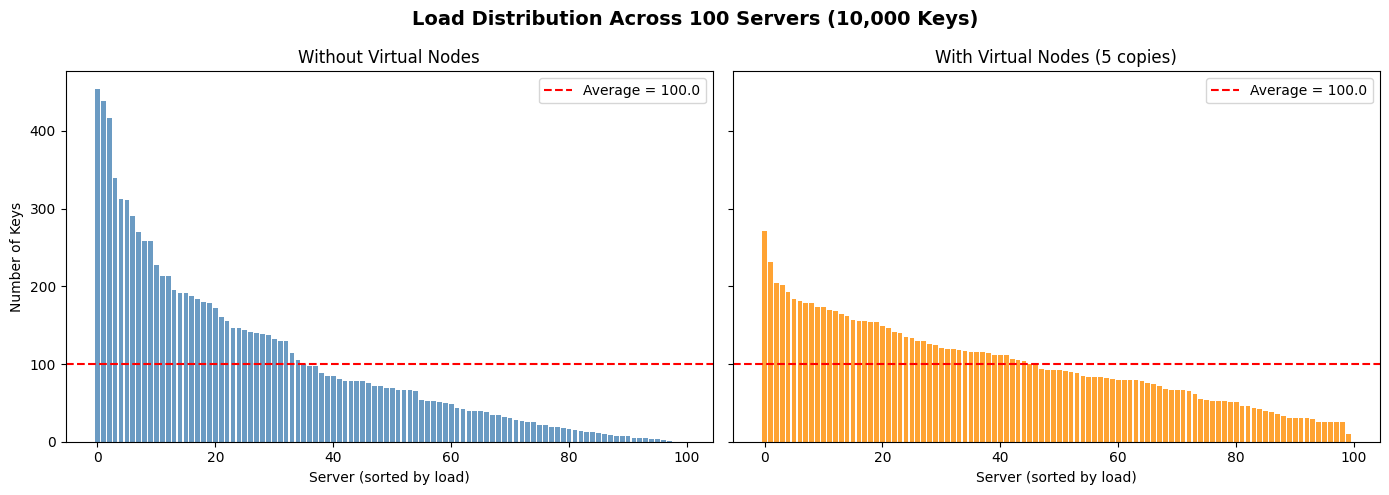

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(range(n_servers), sorted(loads_no_virtual, reverse=True), color='steelblue', alpha=0.8)
axes[0].axhline(y=np.mean(loads_no_virtual), color='red', linestyle='--', label=f'Average = {np.mean(loads_no_virtual):.1f}')
axes[0].set_title('Without Virtual Nodes')
axes[0].set_xlabel('Server (sorted by load)')
axes[0].set_ylabel('Number of Keys')
axes[0].legend()

axes[1].bar(range(n_servers), sorted(loads_virtual, reverse=True), color='darkorange', alpha=0.8)
axes[1].axhline(y=np.mean(loads_virtual), color='red', linestyle='--', label=f'Average = {np.mean(loads_virtual):.1f}')
axes[1].set_title('With Virtual Nodes (5 copies)')
axes[1].set_xlabel('Server (sorted by load)')
axes[1].legend()

fig.suptitle('Load Distribution Across 100 Servers (10,000 Keys)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

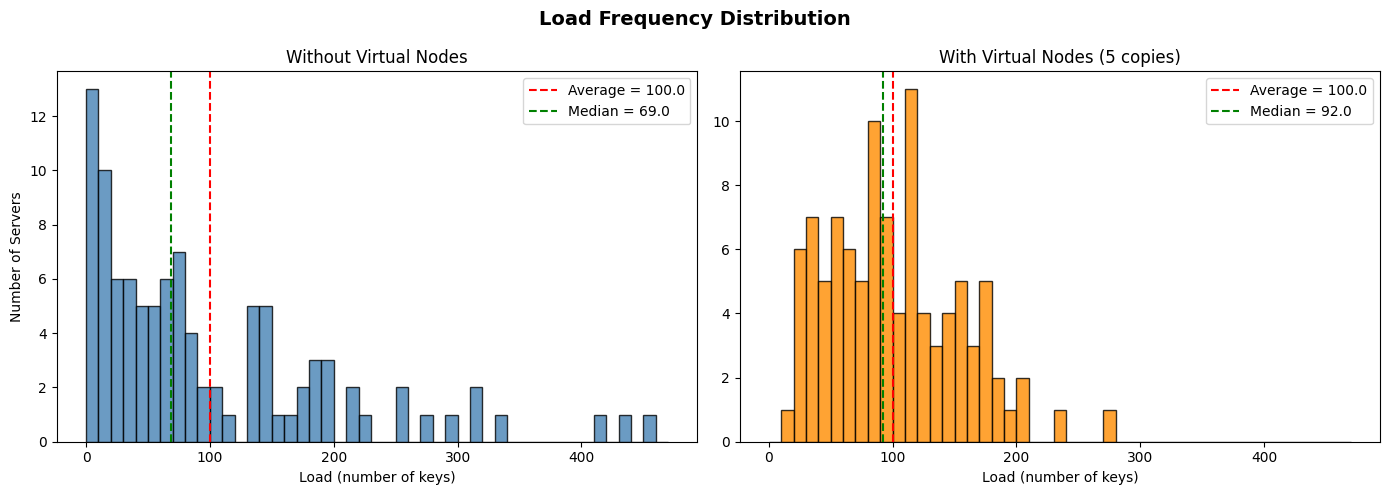

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0, max(loads_no_virtual.max(), loads_virtual.max()) + 20, 10)

axes[0].hist(loads_no_virtual, bins=bins, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].axvline(x=np.mean(loads_no_virtual), color='red', linestyle='--', label=f'Average = {np.mean(loads_no_virtual):.1f}')
axes[0].axvline(x=np.median(loads_no_virtual), color='green', linestyle='--', label=f'Median = {np.median(loads_no_virtual):.1f}')
axes[0].set_title('Without Virtual Nodes')
axes[0].set_xlabel('Load (number of keys)')
axes[0].set_ylabel('Number of Servers')
axes[0].legend()

axes[1].hist(loads_virtual, bins=bins, color='darkorange', alpha=0.8, edgecolor='black')
axes[1].axvline(x=np.mean(loads_virtual), color='red', linestyle='--', label=f'Average = {np.mean(loads_virtual):.1f}')
axes[1].axvline(x=np.median(loads_virtual), color='green', linestyle='--', label=f'Median = {np.median(loads_virtual):.1f}')
axes[1].set_title('With Virtual Nodes (5 copies)')
axes[1].set_xlabel('Load (number of keys)')
axes[1].legend()

fig.suptitle('Load Frequency Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()